**Loading the Dataset**

In [22]:
#Import libraries
import sys
print(sys.executable)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow_hub as hub
import textattack
from textattack.models.wrappers import ModelWrapper
# Load the training data

#Replace the path above with the folder where YOUR file is saved
#Example: train_data = pd.read_csv("C:/Users/YourName/Documents/train.csv")
df = pd.read_csv("C:\\Users\\pande\\archive\\spam.csv", encoding='latin-1')
df.head()


c:\Program Files (x86)\Microsoft Visual Studio\Shared\Python39_64\python.exe


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


**Basic Data Cleaning (Preprocessing)**

In [23]:
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df = df.rename(columns={'v1': 'label', 'v2': 'Text'})
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,Text,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


**Splitting the Data**

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Text'],
    df['label_enc'],
    test_size=0.2,
    random_state=42
)

X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

In [25]:
avg_words_len = round(sum([len(i.split())
                      for i in df['Text']]) / len(df['Text']))
total_words_length = len(set(" ".join(df['Text']).split()))

print(f"Data Loaded. Training samples: {len(X_train_np)}")
print(f"Average words per message: {avg_words_len}")
print(f"Approximate vocabulary size: {total_words_length}")

Data Loaded. Training samples: 4457
Average words per message: 15
Approximate vocabulary size: 15585


In [26]:
def compile_and_fit(model, epochs=5):
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train_np,
        y_train_np,
        epochs=epochs,
        validation_data=(X_test_np, y_test_np)
    )
    return history

def get_metrics(model, X, y):
    y_preds = np.round(model.predict(X))
    return {
        'accuracy': accuracy_score(y, y_preds),
        'precision': precision_score(y, y_preds),
        'recall': recall_score(y, y_preds),
        'f1-score': f1_score(y, y_preds)
    }

In [27]:
from tensorflow.keras.layers import TextVectorization
text_vec = TextVectorization(
    max_tokens=total_words_length,
    standardize='lower_and_strip_punctuation',
    output_mode='int',
    output_sequence_length=avg_words_len
)
text_vec.adapt(X_train_np)

**Training a Basic Classification Model**

Defining Dense Embedding Model

In [28]:

input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_1 = keras.Model(input_layer, output_layer, name="Dense_Model")
history_1 = compile_and_fit(model_1)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8603 - loss: 0.4196 - val_accuracy: 0.9659 - val_loss: 0.1507
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9795 - loss: 0.1013 - val_accuracy: 0.9758 - val_loss: 0.0870
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9900 - loss: 0.0400 - val_accuracy: 0.9803 - val_loss: 0.0768
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9977 - loss: 0.0127 - val_accuracy: 0.9803 - val_loss: 0.0786
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9989 - loss: 0.0089 - val_accuracy: 0.9794 - val_loss: 0.0829


Defining Bi - LSTM Model

In [29]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_2 = keras.Model(input_layer, output_layer, name="BiLSTM_Model")
history_2 = compile_and_fit(model_2)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - accuracy: 0.8976 - loss: 0.2884 - val_accuracy: 0.9776 - val_loss: 0.0851
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9918 - loss: 0.0324 - val_accuracy: 0.9758 - val_loss: 0.0864
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9978 - loss: 0.0105 - val_accuracy: 0.9794 - val_loss: 0.1059
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9997 - loss: 0.0018 - val_accuracy: 0.9794 - val_loss: 0.1165
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 1.0000 - loss: 1.0352e-04 - val_accuracy: 0.9794 - val_loss: 0.1267


Defining USE Model

In [30]:
use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False,
    input_shape=[],
    dtype=tf.string,
    name='USE'
)
input_layer = layers.Input(shape=[], dtype=tf.string)
embedding = layers.Lambda(lambda x: use_layer(
    x), output_shape=(512,))(input_layer)
x = layers.Dense(64, activation='relu')(embedding)
x = layers.Dropout(0.2)(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)
model_3 = keras.Model(input_layer, output_layer, name="USE_Model")
history_3 = compile_and_fit(model_3)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8679 - loss: 0.4315 - val_accuracy: 0.9713 - val_loss: 0.1062
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9811 - loss: 0.0824 - val_accuracy: 0.9785 - val_loss: 0.0679
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9833 - loss: 0.0581 - val_accuracy: 0.9794 - val_loss: 0.0575
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9867 - loss: 0.0466 - val_accuracy: 0.9812 - val_loss: 0.0523
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9898 - loss: 0.0358 - val_accuracy: 0.9857 - val_loss: 0.0502


Getting Results

In [31]:
results = {
    'Dense Embedding': get_metrics(model_1, X_test_np, y_test_np),
    'Bi-LSTM': get_metrics(model_2, X_test_np, y_test_np),
    'Transfer Learning (USE)': get_metrics(model_3, X_test_np, y_test_np)
}

results_df = pd.DataFrame(results).transpose()
print("Performance Table:")
print(results_df)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
Performance Table:
                         accuracy  precision    recall  f1-score
Dense Embedding          0.979372   0.970370  0.873333  0.919298
Bi-LSTM                  0.979372   0.950355  0.893333  0.920962
Transfer Learning (USE)  0.985650   0.978571  0.913333  0.944828


Plotting Results

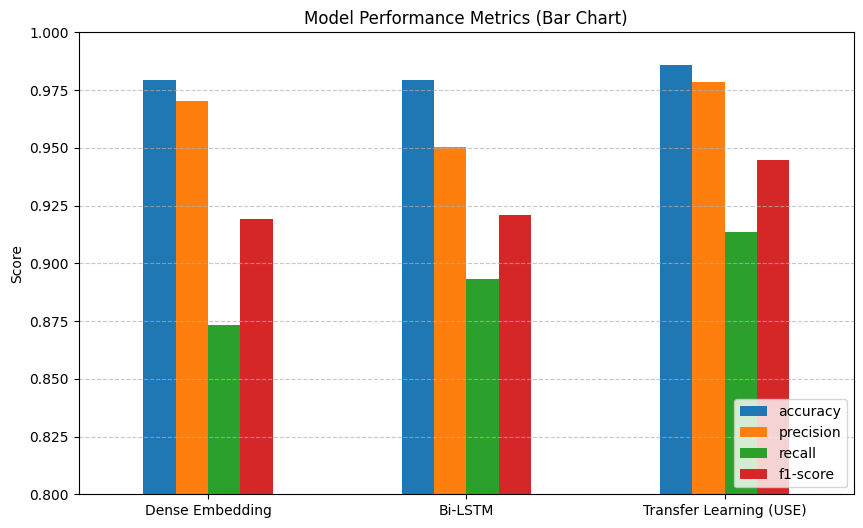

In [32]:
results_df.plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Metrics (Bar Chart)")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

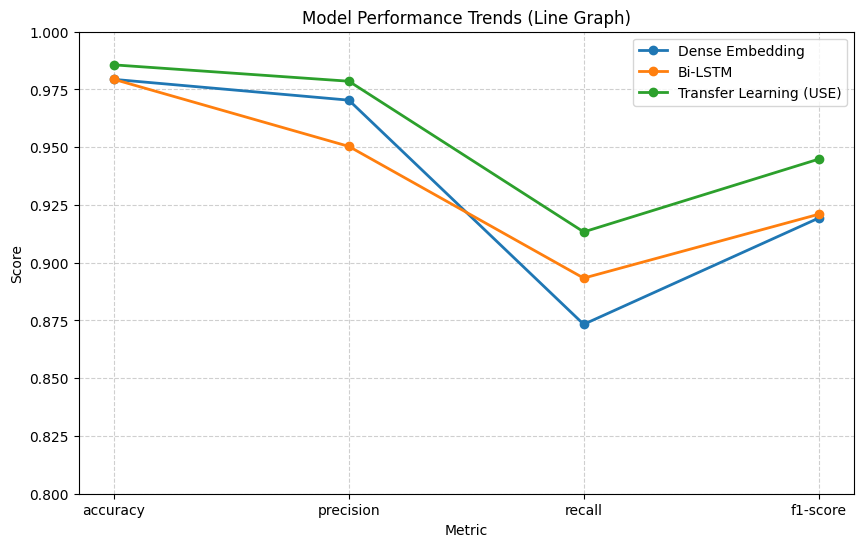

In [33]:
plt.figure(figsize=(10, 6))

for model_name in results_df.index:
    plt.plot(
        results_df.columns,
        results_df.loc[model_name],
        marker='o',
        label=model_name,
        linewidth=2
    )
plt.title("Model Performance Trends (Line Graph)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0.8, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Creating Class Wrapper

In [34]:
#defining wrapper class to use textattack
class CustomModelWrapper:
    def __init__(self,model,):
        self.model=model

    def __call__(self,text):
        inputs = np.array(text).flatten()
        
        # 2. Convert to a TensorFlow String Tensor
        # This is the critical step to fix the 'Invalid dtype' error
        tf_inputs = tf.constant(inputs, dtype=tf.string)
        
        # 3. Get predictions (verbose=0 keeps the console clean during attacks)
        preds = self.model.predict(tf_inputs, verbose=0)
        if preds.shape[1] == 1:
            return np.array([[1-p[0], p[0]] for p in preds])
        return preds
#creating wrapper objects
embed_wrapper=CustomModelWrapper(model_1)
lstm_wrapper=CustomModelWrapper(model_2)
use_wrapper=CustomModelWrapper(model_3)


Creating Attack Samples - Bi - LSTM

In [ ]:
from textattack.attack_recipes import TextBuggerLi2018
from textattack.attacker import Attacker,AttackArgs
from textattack.datasets import Dataset

lstm_attack = TextBuggerLi2018.build(lstm_wrapper)
samples = list(zip(X_test,y_test))

# Convert to the TextAttack-specific Dataset format
attack_dataset = Dataset(samples)
attack_args = AttackArgs(
    num_examples=100, 
    log_to_csv="textbugger_results_lstm.csv"
)

attacker = Attacker(lstm_attack, attack_dataset, attack_args)
results = attacker.attack_dataset()

textattack: Unknown if model of class <class 'keras.src.models.functional.Functional'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.
textattack: Logging to CSV at path textbugger_results_lstm.csv


Attack(
  (search_method): GreedyWordSwapWIR(
    (wir_method):  delete
  )
  (goal_function):  UntargetedClassification
  (transformation):  CompositeTransformation(
    (0): WordSwapRandomCharacterInsertion(
        (random_one):  True
      )
    (1): WordSwapRandomCharacterDeletion(
        (random_one):  True
      )
    (2): WordSwapNeighboringCharacterSwap(
        (random_one):  True
      )
    (3): WordSwapHomoglyphSwap
    (4): WordSwapEmbedding(
        (max_candidates):  5
        (embedding):  WordEmbedding
      )
    )
  (constraints): 
    (0): UniversalSentenceEncoder(
        (metric):  angular
        (threshold):  0.8
        (window_size):  inf
        (skip_text_shorter_than_window):  False
        (compare_against_original):  True
      )
    (1): RepeatModification
    (2): StopwordModification
  (is_black_box):  True
) 



[Succeeded / Failed / Skipped / Total] 0 / 0 / 1 / 1:   0%|          | 1/600 [00:00<01:22,  7.22it/s]

--------------------------------------------- Result 1 ---------------------------------------------
[[1 (100%)]] --> [[[SKIPPED]]]

Funny fact Nobody teaches volcanoes 2 erupt, tsunamis 2 arise, hurricanes 2 sway aroundn no 1 teaches hw 2 choose a wife Natural disasters just happens




[Succeeded / Failed / Skipped / Total] 0 / 1 / 1 / 2:   0%|          | 2/600 [00:15<1:19:32,  7.98s/it]

...

--------------------------------------------- Result 598 ---------------------------------------------
[[1 (100%)]] --> [[0 (82%)]]

**[[FREE]] MESSAGE**Thanks for using the [[Auction]] [[Subscription]] [[Service]]. [[18]] . [[150p]]/MSGRCVD 2 Skip an Auction txt OUT. 2 Unsubscribe txt STOP CustomerCare 08718726270

**[[FR]] [[EE]] MESSAGE**Thanks for using the [[Auctions]] [[Subcription]] [[Serivce]]. [[1Ȣ]] . [[15]] [[0p]]/MSGRCVD 2 Skip an Auction txt OUT. 2 Unsubscribe txt STOP CustomerCare 08718726270




[Succeeded / Failed / Skipped / Total] 118 / 469 / 12 / 599: 100%|█████████▉| 599/600 [08:24<00:00,  1.19it/s]

--------------------------------------------- Result 599 ---------------------------------------------
[[0 (100%)]] --> [[[FAILED]]]

Ok darlin i supose it was ok i just worry too much.i have to do some film stuff my mate and then have to babysit again! But you can call me there.xx




[Succeeded / Failed / Skipped / Total] 119 / 469 / 12 / 600: 100%|██████████| 600/600 [08:25<00:00,  1.19it/s]

--------------------------------------------- Result 600 ---------------------------------------------
[[1 (100%)]] --> [[0 (86%)]]

Want [[2]] get laid tonight? Want [[real]] Dogging locations sent [[direct]] 2 [[ur]] Mob? Join the UK's largest Dogging Network by txting MOAN to 69888Nyt. ec2a. 31p.msg@150p

Want [[ᒿ]] get laid tonight? Want [[re]] [[al]] Dogging locations sent [[di]] [[rect]] 2 [[whats]] Mob? Join the UK's largest Dogging Network by txting MOAN to 69888Nyt. ec2a. 31p.msg@150p



+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 119    |
| Number of failed attacks:     | 469    |
| Number of skipped attacks:    | 12     |
| Original accuracy:            | 98.0%  |
| Accuracy under attack:        | 78.17% |
| Attack success rate:          | 20.24% |
| Average perturbed word %:     | 53.19% |
| Average num. words per input: | 15.79  |
| Avg num queries:       

Creating Attack Samples - USE

In [ ]:
use_attack = TextBuggerLi2018.build(use_wrapper)
samples = list(zip(X_test,y_test))

# Convert to the TextAttack-specific Dataset format
attack_dataset = Dataset(samples)
attack_args = AttackArgs(
    num_examples=100, 
    log_to_csv="textbugger_results_use.csv"
)

attacker = Attacker(use_attack, attack_dataset, attack_args)
results = attacker.attack_dataset()

textattack: Unknown if model of class <class 'keras.src.models.functional.Functional'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.
textattack: Logging to CSV at path textbugger_results_use.csv


Attack(
  (search_method): GreedyWordSwapWIR(
    (wir_method):  delete
  )
  (goal_function):  UntargetedClassification
  (transformation):  CompositeTransformation(
    (0): WordSwapRandomCharacterInsertion(
        (random_one):  True
      )
    (1): WordSwapRandomCharacterDeletion(
        (random_one):  True
      )
    (2): WordSwapNeighboringCharacterSwap(
        (random_one):  True
      )
    (3): WordSwapHomoglyphSwap
    (4): WordSwapEmbedding(
        (max_candidates):  5
        (embedding):  WordEmbedding
      )
    )
  (constraints): 
    (0): UniversalSentenceEncoder(
        (metric):  angular
        (threshold):  0.8
        (window_size):  inf
        (skip_text_shorter_than_window):  False
        (compare_against_original):  True
      )
    (1): RepeatModification
    (2): StopwordModification
  (is_black_box):  True
) 



[Succeeded / Failed / Skipped / Total] 1 / 0 / 0 / 1:   0%|          | 1/600 [00:15<2:37:01, 15.73s/it]

--------------------------------------------- Result 1 ---------------------------------------------
[[0 (99%)]] --> [[1 (51%)]]

[[Funny]] fact [[Nobody]] [[teaches]] volcanoes 2 erupt, tsunamis 2 arise, hurricanes 2 sway [[aroundn]] no 1 teaches [[hw]] 2 choose a [[wife]] Natural disasters just happens

[[Amusing]] fact [[Anyone]] [[teacհes]] volcanoes 2 erupt, tsunamis 2 arise, hurricanes 2 sway [[ɑroundn]] no 1 teaches [[hԝ]] 2 choose a [[femme]] Natural disasters just happens




[Succeeded / Failed / Skipped / Total] 2 / 0 / 1 / 3:   0%|          | 3/600 [00:17<56:44,  5.70s/it]  

...

--------------------------------------------- Result 598 ---------------------------------------------
[[1 (100%)]] --> [[[FAILED]]]

**FREE MESSAGE**Thanks for using the Auction Subscription Service. 18 . 150p/MSGRCVD 2 Skip an Auction txt OUT. 2 Unsubscribe txt STOP CustomerCare 08718726270




[Succeeded / Failed / Skipped / Total] 122 / 471 / 6 / 599: 100%|█████████▉| 599/600 [08:04<00:00,  1.24it/s]

--------------------------------------------- Result 599 ---------------------------------------------
[[0 (100%)]] --> [[[FAILED]]]

Ok darlin i supose it was ok i just worry too much.i have to do some film stuff my mate and then have to babysit again! But you can call me there.xx




[Succeeded / Failed / Skipped / Total] 123 / 471 / 6 / 600: 100%|██████████| 600/600 [08:05<00:00,  1.23it/s]

--------------------------------------------- Result 600 ---------------------------------------------
[[1 (100%)]] --> [[0 (53%)]]

Want 2 get laid tonight? [[Want]] [[real]] Dogging [[locations]] [[sent]] direct 2 ur Mob? [[Join]] the [[UK's]] [[largest]] Dogging Network by [[txting]] MOAN to 69888Nyt. ec2a. 31p.msg@150p

Want 2 get laid tonight? [[Wanna]] [[reaⅼ]] Dogging [[locatіons]] [[forwarded]] direct 2 ur Mob? [[J]] [[oin]] the [[UK`s]] [[lar]] [[gest]] Dogging Network by [[txtng]] MOAN to 69888Nyt. ec2a. 31p.msg@150p



+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 123    |
| Number of failed attacks:     | 471    |
| Number of skipped attacks:    | 6      |
| Original accuracy:            | 99.0%  |
| Accuracy under attack:        | 78.5%  |
| Attack success rate:          | 20.71% |
| Average perturbed word %:     | 27.74% |
| Average num. words per input: | 

Creating Attack Samples - Dense Embedding

In [ ]:
embed_attack = TextBuggerLi2018.build(embed_wrapper)
samples = list(zip(X_test,y_test))

# Convert to the TextAttack-specific Dataset format
attack_dataset = Dataset(samples)
attack_args = AttackArgs(
    num_examples=100, 
    log_to_csv="textbugger_results_embed.csv"
)

attacker = Attacker(embed_attack, attack_dataset, attack_args)
results = attacker.attack_dataset()

textattack: Unknown if model of class <class 'keras.src.models.functional.Functional'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.
textattack: Logging to CSV at path textbugger_results_embed.csv


Attack(
  (search_method): GreedyWordSwapWIR(
    (wir_method):  delete
  )
  (goal_function):  UntargetedClassification
  (transformation):  CompositeTransformation(
    (0): WordSwapRandomCharacterInsertion(
        (random_one):  True
      )
    (1): WordSwapRandomCharacterDeletion(
        (random_one):  True
      )
    (2): WordSwapNeighboringCharacterSwap(
        (random_one):  True
      )
    (3): WordSwapHomoglyphSwap
    (4): WordSwapEmbedding(
        (max_candidates):  5
        (embedding):  WordEmbedding
      )
    )
  (constraints): 
    (0): UniversalSentenceEncoder(
        (metric):  angular
        (threshold):  0.8
        (window_size):  inf
        (skip_text_shorter_than_window):  False
        (compare_against_original):  True
      )
    (1): RepeatModification
    (2): StopwordModification
  (is_black_box):  True
) 



[Succeeded / Failed / Skipped / Total] 0 / 0 / 1 / 1:   0%|          | 1/600 [00:00<01:22,  7.30it/s]

--------------------------------------------- Result 1 ---------------------------------------------
[[1 (81%)]] --> [[[SKIPPED]]]

Funny fact Nobody teaches volcanoes 2 erupt, tsunamis 2 arise, hurricanes 2 sway aroundn no 1 teaches hw 2 choose a wife Natural disasters just happens




[Succeeded / Failed / Skipped / Total] 0 / 1 / 1 / 2:   0%|          | 2/600 [00:17<1:25:25,  8.57s/it]

...

--------------------------------------------- Result 598 ---------------------------------------------
[[1 (100%)]] --> [[[FAILED]]]

**FREE MESSAGE**Thanks for using the Auction Subscription Service. 18 . 150p/MSGRCVD 2 Skip an Auction txt OUT. 2 Unsubscribe txt STOP CustomerCare 08718726270




[Succeeded / Failed / Skipped / Total] 100 / 491 / 8 / 599: 100%|█████████▉| 599/600 [09:37<00:00,  1.04it/s]

--------------------------------------------- Result 599 ---------------------------------------------
[[0 (100%)]] --> [[[FAILED]]]

Ok darlin i supose it was ok i just worry too much.i have to do some film stuff my mate and then have to babysit again! But you can call me there.xx




[Succeeded / Failed / Skipped / Total] 101 / 491 / 8 / 600: 100%|██████████| 600/600 [09:38<00:00,  1.04it/s]

--------------------------------------------- Result 600 ---------------------------------------------
[[1 (100%)]] --> [[0 (71%)]]

Want [[2]] get laid tonight? Want [[real]] Dogging locations sent [[direct]] 2 [[ur]] Mob? Join the UK's largest Dogging Network by txting MOAN to 69888Nyt. ec2a. 31p.msg@150p

Want [[ᒿ]] get laid tonight? Want [[r]] [[eal]] Dogging locations sent [[dire]] [[ct]] 2 [[whats]] Mob? Join the UK's largest Dogging Network by txting MOAN to 69888Nyt. ec2a. 31p.msg@150p



+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 101    |
| Number of failed attacks:     | 491    |
| Number of skipped attacks:    | 8      |
| Original accuracy:            | 98.67% |
| Accuracy under attack:        | 81.83% |
| Attack success rate:          | 17.06% |
| Average perturbed word %:     | 51.44% |
| Average num. words per input: | 15.79  |
| Avg num queries:       

Adding Successful Attacks to Training Data

In [38]:
lstm_results_df=pd.read_csv("textbugger_results_lstm.csv")
use_results_df=pd.read_csv("textbugger_results_use.csv")
embed_results_df=pd.read_csv("textbugger_results_embed.csv")

successful_lstm_rows=lstm_results_df[lstm_results_df['result_type']=='Successful']
successful_lstm_texts=successful_lstm_rows['perturbed_text'].values

successful_use_rows=use_results_df[use_results_df['result_type']=='Successful']
successful_use_texts=successful_use_rows['perturbed_text'].values

successful_embed_rows=embed_results_df[embed_results_df['result_type']=='Successful']
successful_embed_texts=successful_embed_rows['perturbed_text'].values


successful_text_label=np.ones(len(successful_lstm_texts)+len(successful_use_texts)+len(successful_embed_texts))
improved_X_train=np.concatenate([X_train_np,successful_lstm_texts,successful_use_texts,successful_embed_texts ])
improved_y_train=np.concatenate([y_train_np,successful_text_label])

print("Old training size:",len(X_train_np))
print("New training size:",len(improved_X_train) )


Old training size: 4457
New training size: 4800


Getting Results with New Training Data

In [39]:
history_1_improved=compile_and_fit(model_1,epochs=3)
history_2_improved=compile_and_fit(model_2,epochs=3)
history_3_improved=compile_and_fit(model_3,epochs=3)

results = {
    'Dense Embedding': get_metrics(model_1, X_test_np, y_test_np),
    'Bi-LSTM': get_metrics(model_2, X_test_np, y_test_np),
    'Transfer Learning (USE)': get_metrics(model_3, X_test_np, y_test_np)
}

Epoch 1/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9990 - loss: 0.0054 - val_accuracy: 0.9776 - val_loss: 0.0961
Epoch 2/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9991 - loss: 0.0056 - val_accuracy: 0.9776 - val_loss: 0.0926
Epoch 3/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9994 - loss: 0.0038 - val_accuracy: 0.9776 - val_loss: 0.0981
Epoch 1/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 1.0000 - loss: 1.6357e-04 - val_accuracy: 0.9740 - val_loss: 0.3842
Epoch 2/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9955 - loss: 0.0296 - val_accuracy: 0.9767 - val_loss: 0.1209
Epoch 3/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9998 - loss: 0.0013 - val_accuracy: 0.9785 - val_loss: 0.1336
Epoch 1/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9896 - loss: 0.0342 - val_accuracy: 0.9848 - val_loss: 0.0492
Epoch 2/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9935 - loss: 0.0287 - val_accurac

Second Round of Attacks - Bi - LSTM

In [43]:
lstm_attack = TextBuggerLi2018.build(lstm_wrapper)
samples = list(zip(X_test,y_test))

attack_dataset = Dataset(samples)
attack_args = AttackArgs(
    num_examples=100, 
    shuffle=True,
    log_to_csv="textbugger_results_second_try_lstm.csv"
)

attacker = Attacker(lstm_attack, attack_dataset, attack_args)
results = attacker.attack_dataset()

textattack: Unknown if model of class <class 'keras.src.models.functional.Functional'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.
textattack: Logging to CSV at path textbugger_results_second_try_lstm.csv


Attack(
  (search_method): GreedyWordSwapWIR(
    (wir_method):  delete
  )
  (goal_function):  UntargetedClassification
  (transformation):  CompositeTransformation(
    (0): WordSwapRandomCharacterInsertion(
        (random_one):  True
      )
    (1): WordSwapRandomCharacterDeletion(
        (random_one):  True
      )
    (2): WordSwapNeighboringCharacterSwap(
        (random_one):  True
      )
    (3): WordSwapHomoglyphSwap
    (4): WordSwapEmbedding(
        (max_candidates):  5
        (embedding):  WordEmbedding
      )
    )
  (constraints): 
    (0): UniversalSentenceEncoder(
        (metric):  angular
        (threshold):  0.8
        (window_size):  inf
        (skip_text_shorter_than_window):  False
        (compare_against_original):  True
      )
    (1): RepeatModification
    (2): StopwordModification
  (is_black_box):  True
) 



[Succeeded / Failed / Skipped / Total] 0 / 1 / 0 / 1:   1%|          | 1/100 [00:10<17:46, 10.77s/it]

--------------------------------------------- Result 1 ---------------------------------------------
[[1 (100%)]] --> [[[FAILED]]]

Please call our customer service representative on 0800 169 6031 between 10am-9pm as you have WON a guaranteed å£1000 cash or å£5000 prize!




[Succeeded / Failed / Skipped / Total] 0 / 2 / 0 / 2:   2%|▏         | 2/100 [00:11<09:41,  5.94s/it]

...

--------------------------------------------- Result 98 ---------------------------------------------
[[0 (100%)]] --> [[[FAILED]]]

How about clothes, jewelry, and trips?




[Succeeded / Failed / Skipped / Total] 16 / 81 / 2 / 99:  99%|█████████▉| 99/100 [01:21<00:00,  1.22it/s]

--------------------------------------------- Result 99 ---------------------------------------------
[[0 (72%)]] --> [[1 (88%)]]

We are pleased to inform that your application for [[Airtel]] Broadband is processed successfully. Your installation will happen within 3 days.

We are pleased to inform that your application for [[Aіrtel]] Broadband is processed successfully. Your installation will happen within 3 days.




[Succeeded / Failed / Skipped / Total] 17 / 81 / 2 / 100: 100%|██████████| 100/100 [01:23<00:00,  1.19it/s]

--------------------------------------------- Result 100 ---------------------------------------------
[[0 (100%)]] --> [[1 (80%)]]

[[Good]] [[afternoon]], my [[boytoy]] ... [[How]] are you feeling [[today]] ? [[Better]] [[I]] [[hope]]? Are you being my good boy? Are you my obedient, slave? Do you please your Queen?

[[Buena]] [[aftenroon]], my [[boyoty]] ... [[Hoԝ]] are you feeling [[t]] [[oday]] ? [[Improved]] [[ich]] [[expectancy]]? Are you being my good boy? Are you my obedient, slave? Do you please your Queen?



+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 17     |
| Number of failed attacks:     | 81     |
| Number of skipped attacks:    | 2      |
| Original accuracy:            | 98.0%  |
| Accuracy under attack:        | 81.0%  |
| Attack success rate:          | 17.35% |
| Average perturbed word %:     | 55.5%  |
| Average num. words per input: | 14.96  |
| 

Second Round of Attacks - USE

In [45]:
use_attack = TextBuggerLi2018.build(use_wrapper)
samples = list(zip(X_test,y_test))

attack_dataset = Dataset(samples)
attack_args = AttackArgs(
    num_examples=100, 
    shuffle=True,
    log_to_csv="textbugger_results_second_try_use.csv"
)

attacker = Attacker(use_attack, attack_dataset, attack_args)
results = attacker.attack_dataset()

textattack: Unknown if model of class <class 'keras.src.models.functional.Functional'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.
textattack: Logging to CSV at path textbugger_results_second_try_use.csv


Attack(
  (search_method): GreedyWordSwapWIR(
    (wir_method):  delete
  )
  (goal_function):  UntargetedClassification
  (transformation):  CompositeTransformation(
    (0): WordSwapRandomCharacterInsertion(
        (random_one):  True
      )
    (1): WordSwapRandomCharacterDeletion(
        (random_one):  True
      )
    (2): WordSwapNeighboringCharacterSwap(
        (random_one):  True
      )
    (3): WordSwapHomoglyphSwap
    (4): WordSwapEmbedding(
        (max_candidates):  5
        (embedding):  WordEmbedding
      )
    )
  (constraints): 
    (0): UniversalSentenceEncoder(
        (metric):  angular
        (threshold):  0.8
        (window_size):  inf
        (skip_text_shorter_than_window):  False
        (compare_against_original):  True
      )
    (1): RepeatModification
    (2): StopwordModification
  (is_black_box):  True
) 



[Succeeded / Failed / Skipped / Total] 1 / 0 / 0 / 1:   1%|          | 1/100 [00:14<23:40, 14.34s/it]

--------------------------------------------- Result 1 ---------------------------------------------
[[1 (100%)]] --> [[0 (57%)]]

Please [[call]] our customer service representative on [[0800]] 169 6031 between [[10am-9pm]] as you have [[WON]] a guaranteed å£1000 cash or å£[[5000]] prize!

Please [[ϲall]] our customer service representative on [[0080]] 169 6031 between [[10am-pm]] as you have [[W]] [[ON]] a guaranteed å£1000 cash or å£[[500]] prize!




[Succeeded / Failed / Skipped / Total] 1 / 1 / 0 / 2:   2%|▏         | 2/100 [00:15<12:26,  7.62s/it]

...

--------------------------------------------- Result 97 ---------------------------------------------
[[0 (100%)]] --> [[[FAILED]]]

\Im at arestaurant eating squid! i will be out about 10:30 wanna dosomething or is that to late?\""




[Succeeded / Failed / Skipped / Total] 22 / 75 / 2 / 99:  99%|█████████▉| 99/100 [01:25<00:00,  1.16it/s]

--------------------------------------------- Result 98 ---------------------------------------------
[[0 (99%)]] --> [[[FAILED]]]

How about clothes, jewelry, and trips?


--------------------------------------------- Result 99 ---------------------------------------------
[[1 (97%)]] --> [[[SKIPPED]]]

We are pleased to inform that your application for Airtel Broadband is processed successfully. Your installation will happen within 3 days.




[Succeeded / Failed / Skipped / Total] 22 / 76 / 2 / 100: 100%|██████████| 100/100 [01:27<00:00,  1.14it/s]

--------------------------------------------- Result 100 ---------------------------------------------
[[0 (100%)]] --> [[[FAILED]]]

Good afternoon, my boytoy ... How are you feeling today ? Better I hope? Are you being my good boy? Are you my obedient, slave? Do you please your Queen?



+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 22     |
| Number of failed attacks:     | 76     |
| Number of skipped attacks:    | 2      |
| Original accuracy:            | 98.0%  |
| Accuracy under attack:        | 76.0%  |
| Attack success rate:          | 22.45% |
| Average perturbed word %:     | 24.29% |
| Average num. words per input: | 14.96  |
| Avg num queries:              | 33.3   |
+-------------------------------+--------+


Second Round of Attacks - Dense Embedding

In [46]:
embed_attack = TextBuggerLi2018.build(embed_wrapper)
samples = list(zip(X_test,y_test))

attack_dataset = Dataset(samples)
attack_args = AttackArgs(
    num_examples=100, 
    shuffle=True,
    log_to_csv="textbugger_results_second_try_embed.csv"
)

attacker = Attacker(embed_attack, attack_dataset, attack_args)
results = attacker.attack_dataset()

textattack: Unknown if model of class <class 'keras.src.models.functional.Functional'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.
textattack: Logging to CSV at path textbugger_results_second_try_embed.csv


Attack(
  (search_method): GreedyWordSwapWIR(
    (wir_method):  delete
  )
  (goal_function):  UntargetedClassification
  (transformation):  CompositeTransformation(
    (0): WordSwapRandomCharacterInsertion(
        (random_one):  True
      )
    (1): WordSwapRandomCharacterDeletion(
        (random_one):  True
      )
    (2): WordSwapNeighboringCharacterSwap(
        (random_one):  True
      )
    (3): WordSwapHomoglyphSwap
    (4): WordSwapEmbedding(
        (max_candidates):  5
        (embedding):  WordEmbedding
      )
    )
  (constraints): 
    (0): UniversalSentenceEncoder(
        (metric):  angular
        (threshold):  0.8
        (window_size):  inf
        (skip_text_shorter_than_window):  False
        (compare_against_original):  True
      )
    (1): RepeatModification
    (2): StopwordModification
  (is_black_box):  True
) 



[Succeeded / Failed / Skipped / Total] 0 / 1 / 0 / 1:   1%|          | 1/100 [00:14<24:32, 14.87s/it]

--------------------------------------------- Result 1 ---------------------------------------------
[[1 (100%)]] --> [[[FAILED]]]

Please call our customer service representative on 0800 169 6031 between 10am-9pm as you have WON a guaranteed å£1000 cash or å£5000 prize!




[Succeeded / Failed / Skipped / Total] 1 / 1 / 0 / 2:   2%|▏         | 2/100 [00:15<12:33,  7.69s/it]

...

--------------------------------------------- Result 98 ---------------------------------------------
[[0 (99%)]] --> [[[FAILED]]]

How about clothes, jewelry, and trips?




[Succeeded / Failed / Skipped / Total] 18 / 79 / 2 / 99:  99%|█████████▉| 99/100 [01:14<00:00,  1.32it/s]

--------------------------------------------- Result 99 ---------------------------------------------
[[0 (95%)]] --> [[1 (73%)]]

[[We]] are pleased to inform that your application for [[Airtel]] Broadband is processed [[successfully]]. Your installation will happen within 3 days.

[[Nous]] are pleased to inform that your application for [[Airteⅼ]] Broadband is processed [[appropriately]]. Your installation will happen within 3 days.




[Succeeded / Failed / Skipped / Total] 18 / 80 / 2 / 100: 100%|██████████| 100/100 [01:17<00:00,  1.29it/s]

--------------------------------------------- Result 100 ---------------------------------------------
[[0 (100%)]] --> [[[FAILED]]]

Good afternoon, my boytoy ... How are you feeling today ? Better I hope? Are you being my good boy? Are you my obedient, slave? Do you please your Queen?



+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 18     |
| Number of failed attacks:     | 80     |
| Number of skipped attacks:    | 2      |
| Original accuracy:            | 98.0%  |
| Accuracy under attack:        | 80.0%  |
| Attack success rate:          | 18.37% |
| Average perturbed word %:     | 36.79% |
| Average num. words per input: | 14.96  |
| Avg num queries:              | 47.92  |
+-------------------------------+--------+
